## Try 8.6.1: *k*-fold cross-validation in Python.

In [1]:
# Import packages and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

In [3]:
# Import dataset
badDrivers = pd.read_csv('bad-drivers.csv')
badDrivers

,State,Number of drivers involved in fatal collisions per billion miles,Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding,Percentage Of Drivers Involved In Fatal Collisions Who Were Alcohol-Impaired,Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted,Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents,Car Insurance Premiums ($),Losses incurred by insurance companies for collisions per insured driver ($)
0,Alabama,18.8,39,30,96,80,784.55,145.08
1,Alaska,18.1,41,25,90,94,1053.48,133.93
2,Arizona,18.6,35,28,84,96,899.47,110.35
3,Arkansas,22.4,18,26,94,95,827.34,142.39
4,California,12.0,35,28,91,89,878.41,165.63
5,Colorado,13.6,37,28,79,95,835.50,139.91
6,Connecticut,10.8,46,36,87,82,1068.73,167.02
7,Delaware,16.2,38,30,87,99,1137.87,151.48
8,District of Columbia,5.9,34,27,100,100,1273.89,136.05
9,Florida,17.9,21,29,92,94,1160.13,144.18


In [4]:
badDrivers.columns

Index(['State',
       'Number of drivers involved in fatal collisions per billion miles',
       'Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding',
       'Percentage Of Drivers Involved In Fatal Collisions Who Were Alcohol-Impaired',
       'Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted',
       'Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents',
       'Car Insurance Premiums ($)',
       'Losses incurred by insurance companies for collisions per insured driver ($)'],
      dtype='object')

In [5]:
badDrivers.isnull().sum()

State                                                                                                     0
Number of drivers involved in fatal collisions per billion miles                                          0
Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding                                      0
Percentage Of Drivers Involved In Fatal Collisions Who Were Alcohol-Impaired                              0
Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted                                0
Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents    0
Car Insurance Premiums ($)                                                                                0
Losses incurred by insurance companies for collisions per insured driver ($)                              0
dtype: int64

In [15]:


# Split off 20% of the data to be left out as test data
badDriversTrainingdata, testData = train_test_split(badDrivers, test_size=0.20)

# Store relevant columns as variables
X_train = badDriversTrainingdata[
    ['Losses incurred by insurance companies for collisions per insured driver ($)']
].values.reshape(-1, 1)
y_train = badDriversTrainingdata[['Car Insurance Premiums ($)']].values.reshape(-1, 1)

In [ ]:
print(X_train.size, y_train.size)

40 40


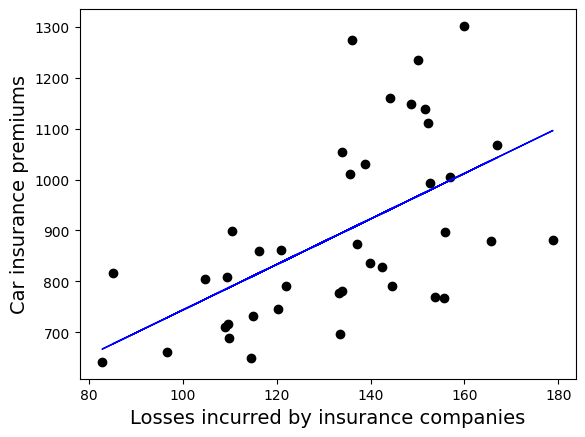

In [21]:
# Fit a linear model to the data
linModel = LinearRegression()
linModel.fit(X_train, y_train)
yPredicted = linModel.predict(X_train)

# Plot the fitted model
plt.scatter(X_train, y_train, color='black')
plt.plot(X_train, yPredicted, color='blue', linewidth=1)
plt.xlabel('Losses incurred by insurance companies', fontsize=14);
plt.ylabel('Car insurance premiums', fontsize=14);

In [23]:
# neg_mean_square_error is the negative MSE, so add a - so the scores are positive.
ten_fold_scores = -cross_val_score(
    linModel, X_train, y_train, scoring='neg_mean_squared_error', cv=10
)

In [19]:
ten_fold_scores

array([12854.29008042, 14011.28536727, 19333.54534803,  7067.30998934,
       28858.98618794, 50091.84506566,  8358.77214019, 17146.99284004,
        7173.30868103, 24233.00876568])

In [19]:
# neg_mean_square_error is the negative MSE, so add a - so the scores are positive.
LOOCV_scores = -cross_val_score(linModel, X_train, y_train, scoring='neg_mean_squared_error', cv=40)

In [24]:
LOOCV_scores

array([5.08071687e+04, 1.93483943e+04, 1.41158791e+04, 6.61831862e+03,
       1.92505136e+03, 2.80970570e+03, 1.19361555e+04, 5.57833213e+03,
       2.92296846e+04, 6.07115328e+04, 5.21541017e+01, 7.59016744e+02,
       2.58821171e+04, 1.83856303e+03, 1.38110236e+04, 2.96089911e+04,
       1.08469396e+04, 1.47340383e+03, 5.09518986e+04, 8.68099198e+02,
       2.47128100e+04, 8.24585949e+03, 2.77792895e+04, 1.22625519e+04,
       6.02591096e+03, 4.04321005e+04, 5.40972780e+03, 7.71177017e+04,
       1.43204617e+05, 5.99307685e+02, 2.62186685e+04, 5.57564367e+04,
       5.89124624e+02, 3.80647112e+04, 1.34516655e+04, 7.96659768e+03,
       1.04530024e+04, 2.07471459e+02, 1.32329908e+04, 9.52944573e+04])

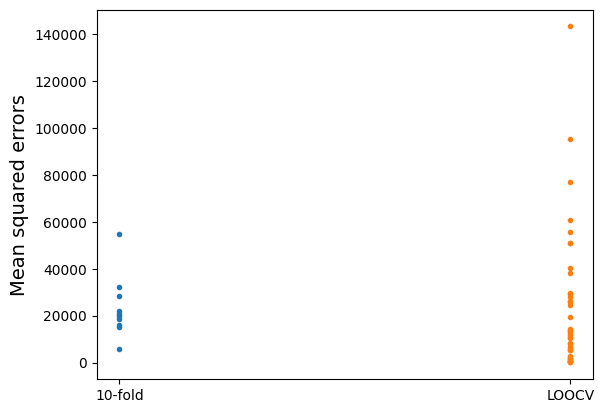

In [20]:
# Plot the errors for both scores
plt.plot(np.zeros_like(ten_fold_scores), ten_fold_scores, '.')
plt.plot(np.zeros_like(LOOCV_scores) + 1, LOOCV_scores, '.')
plt.ylabel('Mean squared errors', fontsize=14);
plt.xticks([0, 1], ['10-fold', 'LOOCV']);

## challenge activity 8.6.2: Cross-validation using scikit-learn.

## 1) Researchers collected measurements from loblolly pines.

**Split the dataset into train and test datasets using the train_test_split() method with the following parameters, respectively:**
 * **the original data frame**
 * **the test_size parameter set to the test proportion**
 * **the random_state parameter set to rng**

**The proportion for the train dataset is 85%.**

**The code provided contains all imports, loads the dataset, initializes the model, calculates the MSE for 10-fold and **k**-fold cross-validation, and prints the average MSE and the set of all MSEs for 10-fold and *k*-fold cross-validation.**

In [32]:
# Import packages and functions

from sklearn.preprocessing import PolynomialFeatures


In [ ]:


rng = np.random.RandomState(49)

# Load the dataset
loblollyPine = pd.read_csv('loblollyPineSample.csv')

# Split dataset into training data and testing data
trainingDataName, testingDataName = # Your code goes here

# Store relevant columns as variables
X = trainingDataName[['age']]
y = trainingDataName[['height']]

# Initialize the model -- quadratic polynomial regression model
polyFeatures = PolynomialFeatures(degree=2, include_bias=False)
xPoly = polyFeatures.fit_transform(X)
quadraticPolynomialRegressionModel = LinearRegression()

# Evaluate accuracy
# neg_mean_square_error is the negative MSE, so append a - so the scores are positive.
tenFoldScores = -cross_val_score(quadraticPolynomialRegressionModel, X, y, scoring='neg_mean_squared_error', cv=10)

print('ten-fold average MSE =', np.mean(tenFoldScores), '\n', tenFoldScores)

# neg_mean_square_error is the negative MSE, so append a minus so the scores are positive.
LOOCVScores = -cross_val_score(quadraticPolynomialRegressionModel, X, y, scoring='neg_mean_squared_error', cv=len(X))

print('\nk-fold average MSE =', np.mean(LOOCVScores), '\n', LOOCVScores)

## 2)Researchers collected measurements from loblolly pines.

* **Calculate the mean squared errors for **k**-fold cross-validation with **k**= 10. Use the negative of the cross_val_score() method with the following parameters, respectively:**
    * **the model variable**
    * **x_variable**
    * **y_variable**
    * **the scoring parameter set to neg_mean_squared_error**
    * **the cv parameter set to 10**

**Both x_variable and y_variable are from the training set.**

**The code provided contains all imports, loads the dataset, splits the dataset into train and test datasets, initializes the model, calculates the MSEs for *k*-fold cross-validation, and prints average MSE and the set of all MSEs for both 10-fold and *k*-fold cross-validation.**

In [ ]:

rng = np.random.RandomState(17)

# Load the dataset
loblollyPine = pd.read_csv('loblollyPineSample.csv')

# Split dataset into training data and testing data
trainDatasetName, testDatasetName = train_test_split(loblollyPine, test_size=0.3, random_state=rng)

# Store relevant columns as variables
X = trainDatasetName[['age']]
y = trainDatasetName[['height']]

# Initialize the model -- quadratic polynomial regression model
polyFeatures = PolynomialFeatures(degree=2, include_bias=False)
xPoly = polyFeatures.fit_transform(X)
polynomialRegressionModel = LinearRegression()

# Evaluate accuracy
# neg_mean_square_error is the negative MSE, so append a minus so the scores are positive.
tenFoldScores = # Your code goes here

print('ten-fold average MSE =', np.mean(tenFoldScores), '\n', tenFoldScores)

# neg_mean_square_error is the negative MSE, so append a - so the scores are positive.
LOOCVScores = -cross_val_score(polynomialRegressionModel, X, y, scoring='neg_mean_squared_error', cv=len(X))

print('\nk-fold average MSE =', np.mean(LOOCVScores), '\n', LOOCVScores)

## 3) Researchers collected measurements from loblolly pines.

Calculate the mean squared errors for **k**-fold cross-validation with *k*= length of the training dataset. Use the negative of the cross_val_score() method with the following parameters, respectively:
the model variable
* **x_variable**
* **y_variable**
* **the scoring parameter set to neg_mean_squared_error**
* **the cv parameter set to len(x_variable)**
  
**Both x_variable and y_variable are from the training set.**

**The code provided contains all imports, loads the dataset, splits the dataset into train and test datasets, initializes the model, calculates the MSEs for *k*-fold cross-validation, and prints average MSE and the set of all MSEs for both 10-fold and *k*-fold cross-validation.**

In [ ]:


rng = np.random.RandomState(8)

# Load the dataset
pines = pd.read_csv('pinesSample.csv')

# Split dataset into training data and testing data
trainDataName, testDataName = train_test_split(pines, test_size=0.3, random_state=rng)

# Store relevant columns as variables
X = trainDataName[['age']]
y = trainDataName[['height']]

# Initialize the model -- quadratic polynomial regression model
polyFeatures = PolynomialFeatures(degree=2, include_bias=False)
xPoly = polyFeatures.fit_transform(X)
quadraticPolynomialRegressionModel = LinearRegression()

# Evaluate accuracy
# neg_mean_square_error is the negative MSE, so append a - so the scores are positive.
tenFoldScores = -cross_val_score(quadraticPolynomialRegressionModel, X, y, scoring='neg_mean_squared_error', cv=10)

print('ten-fold average MSE =', np.mean(tenFoldScores), '\n', tenFoldScores)

# neg_mean_square_error is the negative MSE, so append a - so the scores are positive.
LOOCVScores = # Your code goes here

print('\nk-fold average MSE =', np.mean(LOOCVScores), '\n', LOOCVScores)